Mounted at /content/drive
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 2607s 18s/step - accuracy: 0.4641 - loss: 1.2149 - val_accuracy: 0.6915 - val_loss: 0.8194 - learning_rate: 1.0000e-05
Epoch 2/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 96s 672ms/step - accuracy: 0.8098 - loss: 0.5326 - val_accuracy: 0.7397 - val_loss: 0.6921 - learning_rate: 1.0000e-05
Epoch 3/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 96s 671ms/step - accuracy: 0.8434 - loss: 0.4143 - val_accuracy: 0.7835 - val_loss: 0.5870 - learning_rate: 1.0000e-05
Epoch 4/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 96s 665ms/step - accuracy: 0.8689 - loss: 0.3699 - val_accuracy: 0.8037 - val_loss: 0.5822 - learning_rate: 1.0000e-05
Epoch 5/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 94s 659ms/step - accuracy: 0.8852 - loss: 0.3180 - val_accuracy: 0.8002 - val_loss: 0.5625 - learning_rate: 1.0000e-05
Epoch 6/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 95s 665ms/step - accuracy: 0.8900 - loss: 0.3056 - val_accuracy: 0.8124 - val_loss: 0.5055 - learning_rate: 1.0000e-05
Epoch 7/40
143/143 ━━━━━━━━━━━━━━━━━━━━ 95s 66

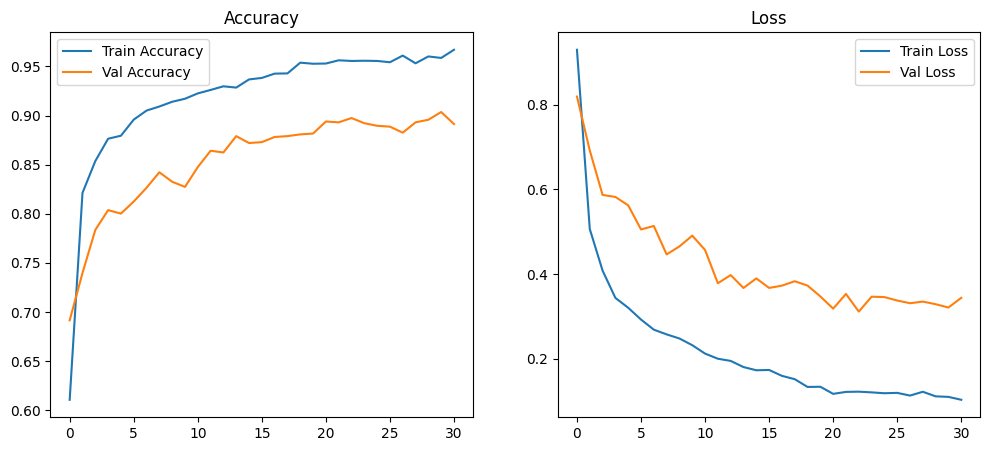

In [ ]:
# ---------------------------
# 1️⃣ Mount Google Drive
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------
# 2️⃣ Set dataset paths
# ---------------------------
train_dir = '/content/drive/MyDrive/MRI_Images/Training/'  # update folder name if needed
test_dir  = '/content/drive/MyDrive/MRI_Images/Testing/'

# ---------------------------
# 3️⃣ Import libraries
# ---------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pickle   # ✅ needed for saving history

# ---------------------------
# 4️⃣ Data Augmentation
# ---------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ---------------------------
# 5️⃣ Load VGG16 Base Model
# ---------------------------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze all layers except last 4
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

# ---------------------------
# 6️⃣ Build Model
# ---------------------------
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------
# 7️⃣ Callbacks
# ---------------------------
checkpoint = ModelCheckpoint(
    '/content/vgg16_brain_tumor_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-7
)

# ---------------------------
# 8️⃣ Train Model
# ---------------------------
EPOCHS = 40

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ---------------------------
# 🔹 Save Training History (.pkl)
# ---------------------------
with open('/content/vgg16_training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("📂 Training history saved as vgg16_training_history.pkl")

# ---------------------------
# 9️⃣ Evaluate on Test Set
# ---------------------------
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

# ---------------------------
# 🔟 Plot Training Curves
# ---------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()


In [ ]:
import pickle
from google.colab import files
from tensorflow.keras.models import load_model

# ---------------------------
# 1️⃣ Save Trained Model
# ---------------------------
model.save("/content/vgg16_brain_tumor.keras")   # New Keras format
model.save("/content/vgg16_brain_tumor.h5")      # Legacy H5 format
print("✅ Models saved successfully")

# ---------------------------
# 2️⃣ Save Best Model (from checkpoint)
# ---------------------------
best_model_path = "/content/vgg16_brain_tumor_best.keras"
print(f"✅ Best model already saved at {best_model_path}")

# ---------------------------
# 3️⃣ Save Training History
# ---------------------------
with open('/content/history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✅ Training history saved as history.pkl")

# ---------------------------
# 4️⃣ Download All Files Locally
# ---------------------------
files.download("/content/vgg16_brain_tumor.keras")
files.download("/content/vgg16_brain_tumor.h5")
files.download("/content/vgg16_brain_tumor_best.keras")
files.download("/content/history.pkl")

# ---------------------------
# 5️⃣ Reload Model & History Later
# ---------------------------
# Example of loading model back:
# loaded_model = load_model("/content/vgg16_brain_tumor.keras")

# Example of loading history back:
# with open("/content/history.pkl", "rb") as f:
#     loaded_history = pickle.load(f)
# print(loaded_history.keys())  # ['loss', 'accuracy', 'val_loss', 'val_accuracy']


✅ Models saved successfully
✅ Best model already saved at /content/vgg16_brain_tumor_best.keras
✅ Training history saved as history.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save entire model (architecture + weights + optimizer state)
model.save('/content/latest_vgg16_brain_tumor_model.keras')
print("✅ Model saved in Keras format")


In [ ]:
model.save_weights('/content/weights_vgg16_brain_tumor_weights.h5')
print("✅ Model weights saved")


41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step


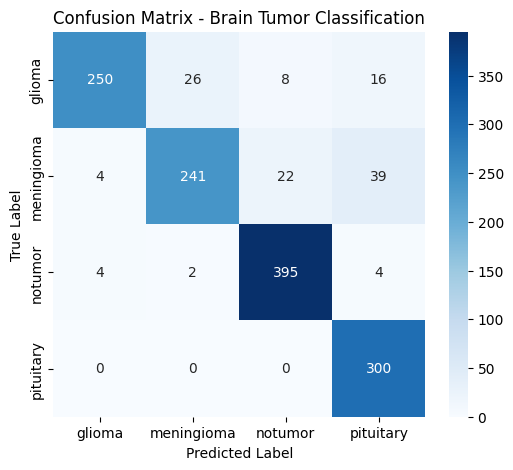

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ---------------------------
# 1️⃣ Generate predictions
# ---------------------------
y_pred_probs = model.predict(test_generator)      # prediction probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # predicted labels
y_true = test_generator.classes                   # true labels
class_names = list(test_generator.class_indices.keys())

# ---------------------------
# 2️⃣ Compute confusion matrix
# ---------------------------
cm = confusion_matrix(y_true, y_pred_classes)

# ---------------------------
# 3️⃣ Plot confusion matrix
# ---------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Brain Tumor Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("/content/confusion_matrix.png")  # ✅ saves the image
plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,144,974 (183.66 MB)

 Trainable params: 13,503,236 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 27,006,474 (103.02 MB)

✅ Model architecture saved as PNG and PDF


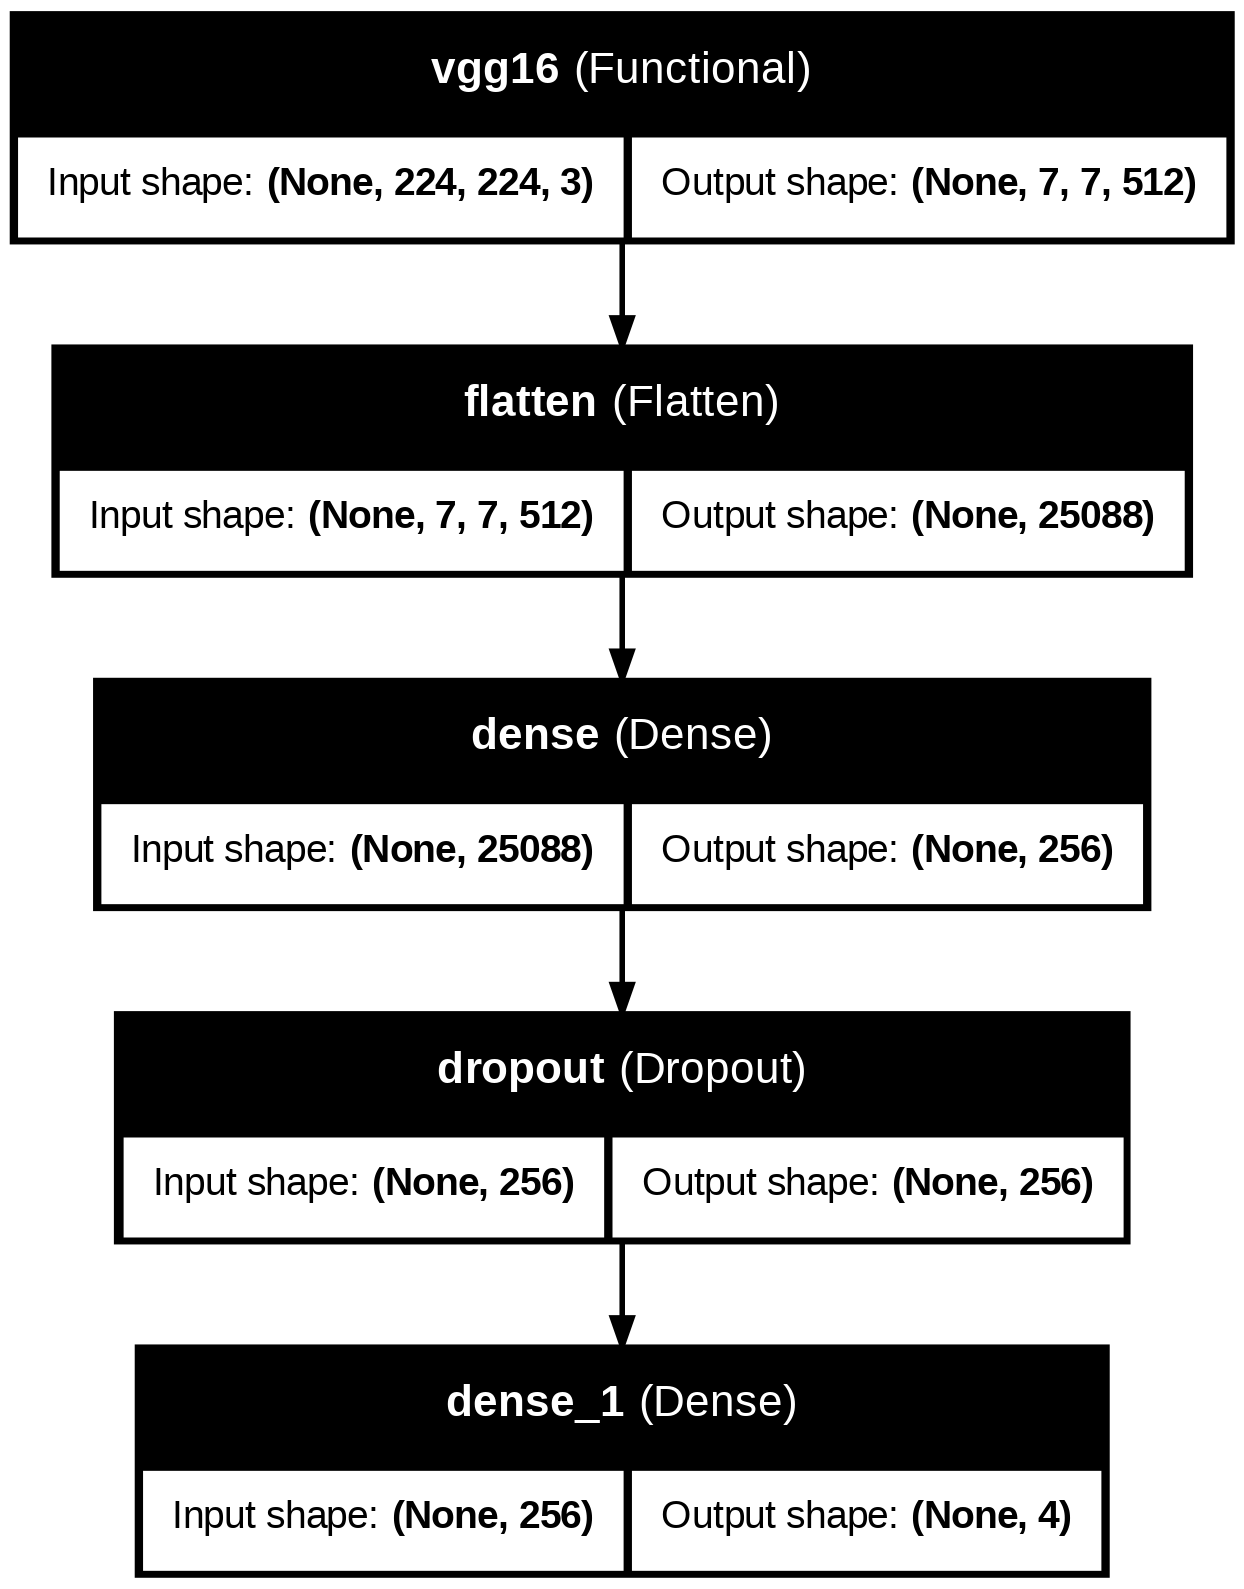

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Print architecture summary (good for IEEE appendix or explanation)
model.summary()
from tensorflow.keras.utils import plot_model

# Save model architecture as PNG
plot_model(model, to_file="/content/vgg16_architecture.png", show_shapes=True, show_layer_names=True)

# Save also as PDF (optional for IEEE paper diagrams)
plot_model(model, to_file="/content/vgg16_architecture.pdf", show_shapes=True, show_layer_names=True)

print("✅ Model architecture saved as PNG and PDF")

from IPython.display import Image, display
from google.colab import files

# ---------------------------
# 1️⃣ Display the PNG image in Colab
# ---------------------------
display(Image("/content/vgg16_architecture.png"))

# ---------------------------
# 2️⃣ Download the PNG and PDF locally
# ---------------------------
files.download("/content/vgg16_architecture.png")
files.download("/content/vgg16_architecture.pdf")



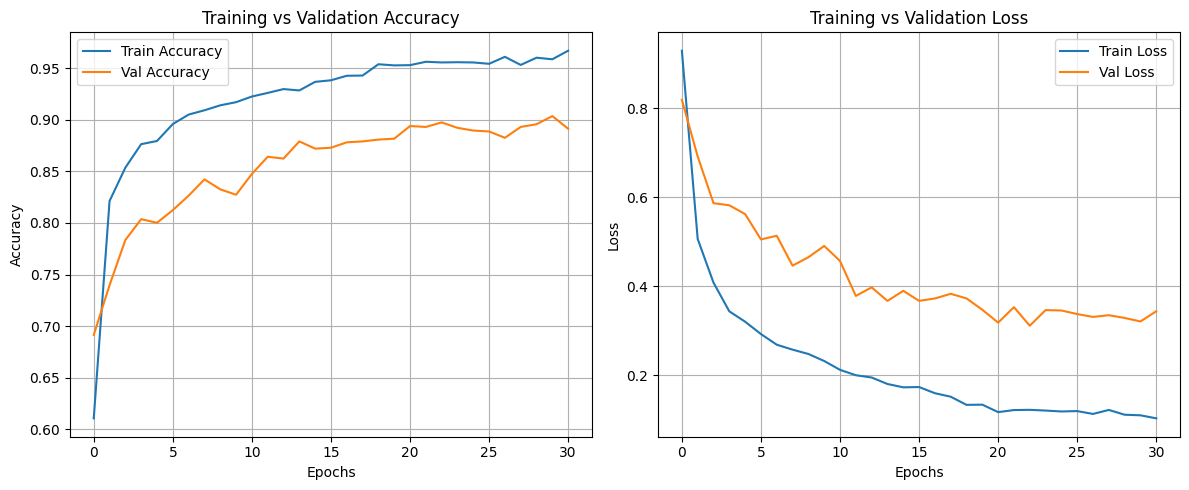

In [ ]:
import matplotlib.pyplot as plt
import pickle

# ---------------------------
# 📉 Training Curves (Accuracy & Loss)
# ---------------------------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/training_curves.png")  # ✅ save as image
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step


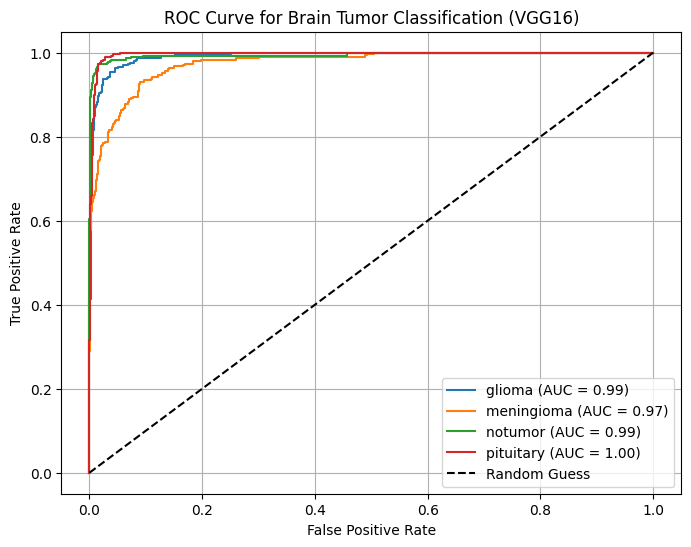

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# ---------------------------
# 1️⃣ Get model predictions
# ---------------------------
y_pred = model.predict(test_generator, verbose=1)
y_true = test_generator.classes

# ---------------------------
# 2️⃣ Binarize the labels (One-hot)
# ---------------------------
class_names = list(test_generator.class_indices.keys())  # ['Glioma', 'Meningioma', 'Pituitary', 'Normal']
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])  # 4 classes

# ---------------------------
# 3️⃣ Plot ROC Curve for each class
# ---------------------------
plt.figure(figsize=(8,6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

# ---------------------------
# 4️⃣ Plot random guess line
# ---------------------------
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.title("ROC Curve for Brain Tumor Classification (VGG16)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("/content/roc_curve.png")  # ✅ save figure
plt.show()


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from google.colab import files

# ---------------------------
# 1️⃣ Classification Report
# ---------------------------
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4)
print("📊 Classification Report:\n")
print(report)

# ---------------------------
# 2️⃣ Overall Performance Metrics
# ---------------------------
accuracy  = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall    = recall_score(y_true, y_pred_classes, average='weighted')
f1        = f1_score(y_true, y_pred_classes, average='weighted')

print("\n✅ Overall Performance Metrics:")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")

# ---------------------------
# 3️⃣ Save report to file
# ---------------------------
file_path = "/content/classification_report.txt"
with open(file_path, "w") as f:
    f.write("Classification Report\n\n")
    f.write(report)
    f.write("\n\n")
    f.write(f"Accuracy : {accuracy*100:.2f}%\n")
    f.write(f"Precision: {precision*100:.2f}%\n")
    f.write(f"Recall   : {recall*100:.2f}%\n")
    f.write(f"F1-score : {f1*100:.2f}%\n")

print("📂 Report saved as classification_report.txt")

# ---------------------------
# 4️⃣ Download to local PC
# ---------------------------
files.download(file_path)


📊 Classification Report:

              precision    recall  f1-score   support

      glioma     0.9690    0.8333    0.8961       300
  meningioma     0.8959    0.7876    0.8383       306
     notumor     0.9294    0.9753    0.9518       405
   pituitary     0.8357    1.0000    0.9105       300

    accuracy                         0.9047      1311
   macro avg     0.9075    0.8991    0.8991      1311
weighted avg     0.9092    0.9047    0.9031      1311


✅ Overall Performance Metrics:
Accuracy : 90.47%
Precision: 90.92%
Recall   : 90.47%
F1-score : 90.31%
📂 Report saved as classification_report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from google.colab import files

# 1️⃣ Pick a test image
img_path = test_generator.filepaths[0]
img = image.load_img(img_path, target_size=(224,224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x /= 255.0

# 2️⃣ Call the model once to define input shapes
_ = model.predict(x)

# 3️⃣ Access base VGG16 from Sequential
base_model = model.layers[0]  # first layer in Sequential

# 4️⃣ Last conv layer in VGG16
last_conv_layer_name = "block5_conv3"
last_conv_layer = base_model.get_layer(last_conv_layer_name)

# 5️⃣ Build Grad-CAM model
grad_model = Model(
    inputs=model.input,  # Sequential input is now defined
    outputs=[last_conv_layer.output, model.output]
)

# 6️⃣ Compute Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

# 7️⃣ Overlay heatmap on original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# 8️⃣ Save and display
gradcam_path = "/content/gradcam_example.png"
cv2.imwrite(gradcam_path, superimposed_img)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

files.download(gradcam_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


AttributeError: The layer sequential has never been called and thus has no defined input.